<h1 style="color:#38BDF8; text-align:center; font-weight:bold; border-bottom:3px solid #38BDF8;">Day 5 — Supervised-Learning Mini-Project</h1>
<h3 style="text-align:center; color:#BE185D;">A Full Pipeline: EDA &rarr; Preprocessing &rarr; Split &rarr; Model &rarr; Evaluation</h3>


<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">Table of Contents</h2>

<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</a></li>
<li><a href="#section1">1. The Full Supervised-Learning Pipeline</a></li>
<li><a href="#section2">2. Basic Preprocessing</a></li>
<li><a href="#section3">3. Choosing the Right Model and Metric</a></li>
<li><a href="#section4">4. Documenting the Result</a></li>
<li><a href="#section5">5. Common Mistakes to Avoid</a></li>
<li><a href="#section6">6. Quick Reference — Cheat Sheet</a></li>
<li><a href="#section7">7. Hands-On Lab — End-to-End Mini-Project</a></li>
<li><a href="#section8">8. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section9">9. Summary — What I Learned This Week</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">0. Setup — Importing Pandas, NumPy &amp; Scikit-learn</h2>
<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> This week we trained a linear regression model (Day 2), a logistic regression classifier (Day 3), and compared four more classifiers (Day 4). Today we combine <b>everything</b> into one clean, end-to-end project — the exact pipeline shape every project in this program follows.
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Pandas version      :", pd.__version__)
print("NumPy version       :", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version      : 2.3.3
NumPy version       : 2.3.5
Scikit-learn version: 1.7.2


<a id="section1"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">1. The Full Supervised-Learning Pipeline</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.1 Five stages, every time</h3>
Every supervised-learning project in this program — and every model we have trained this week — follows the same five-stage shape:

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;"><th style="padding:8px; text-align:left;">Stage</th><th style="padding:8px; text-align:left;">What Happens</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">1. EDA</td><td style="padding:8px; border-top:1px solid #eee;">Understand the data (Week 2 methodology): distributions, correlations, problems</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">2. Preprocessing</td><td style="padding:8px; border-top:1px solid #eee;">Handle missing values, encode categories, scale features</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">3. Train/test split</td><td style="padding:8px; border-top:1px solid #eee;">Hold out unseen data for honest evaluation</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">4. Modeling</td><td style="padding:8px; border-top:1px solid #eee;">Train one or more models via the Scikit-learn API</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">5. Evaluation</td><td style="padding:8px; border-top:1px solid #eee;">Measure performance with appropriate metrics vs. a baseline</td></tr>
</table>
</div>


<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> This is also the exact structure the <b>Phase 3 capstone</b> project will formalize — today is a full rehearsal of that pipeline on a smaller scale.
</div>


<a id="section2"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">2. Basic Preprocessing</h2>
<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 Encoding categorical features</h3>
Categorical features (text categories like <code>"male"</code>/<code>"female"</code>) must be converted to numbers, since models only accept numeric input. <b>One-hot encoding</b> is the standard method — it turns a category column into one 0/1 column per category.

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.2 Scaling numeric features</h3>
Feature scaling puts all numeric features on a comparable range, which matters greatly for distance- and margin-based models like k-NN and SVM (Day 4) — a feature measured in the thousands (like <code>Fare</code>) would otherwise dominate a feature measured in single digits (like <code>Pclass</code>).

In [2]:
from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled  = scaler.transform(X_test)   # note: transform only, never fit on test

print("We will fit and apply a real scaler in Section 7 (Hands-On Lab).")

We will fit and apply a real scaler in Section 7 (Hands-On Lab).


<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> <b>Critical rule:</b> fit the scaler on the <b>training data only</b>, then apply it to the test data with <code>.transform()</code>. Fitting on the full dataset <b>leaks</b> information from the test set into training and inflates results — a subtle but serious mistake called <b>data leakage</b>.
</div>


<a id="section3"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">3. Choosing the Right Model and Metric</h2>
A real project requires two decisions, not just running code:
<ul>
<li><b>Is the task regression or classification?</b> This determines which models and metrics apply (Day 1's distinction).</li>
<li><b>Which metric best reflects success for this specific problem?</b> Accuracy alone, or precision/recall/F1 (Day 3), or MAE/RMSE/R&sup2; (Day 2) — the right choice depends on the problem, not a formula.</li>
</ul>
Making and justifying these choices — not just calling <code>.fit()</code> — is what separates a real project from a coding exercise.

<a id="section4"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">4. Documenting the Result</h2>
The deliverable of a real project is never just a trained model — it is a <b>clean, narrated notebook</b>: each stage explained in Markdown, each choice justified, and the final result compared honestly against a baseline. This is the same standard applied to every notebook in the program, and the foundation for the technical write-ups expected in Phase 3.

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> A model's raw metric means little on its own. Always state, explicitly, what it beat — a naive baseline, a simpler model, or last week's result — so the reader can judge whether the extra complexity was worth it.
</div>


<a id="section5"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">5. Common Mistakes to Avoid</h2>
<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> <ul>
<li><b>Fitting the scaler (or encoder) on the full dataset</b> — always fit on <code>X_train</code> only, then transform both train and test.</li>
<li><b>Skipping EDA</b> — training a model on data you have not looked at risks missing obvious problems (missing values, wrong types, outliers).</li>
<li><b>Reporting a metric with no baseline</b> — a raw number means nothing without something to compare it against.</li>
<li><b>Picking a metric after seeing the results</b> — decide which metric matters for the problem <i>before</i> evaluating, or the choice risks being biased toward whichever number looks best.</li>
<li><b>Leaving the notebook uncommented</b> — a notebook without Markdown narration is not a finished deliverable, even if the code runs correctly.</li>
</ul>
</div>


<a id="section6"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">6. Quick Reference — Cheat Sheet</h2>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;"><th style="padding:8px; text-align:left;">Task</th><th style="padding:8px; text-align:left;">Code</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">Encode categoricals</td><td style="padding:8px; border-top:1px solid #eee;"><code>pd.get_dummies(df, columns=[...], drop_first=True)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">Scale features (fit)</td><td style="padding:8px; border-top:1px solid #eee;"><code>scaler = StandardScaler()</code><br><code>X_train_scaled = scaler.fit_transform(X_train)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">Scale features (apply)</td><td style="padding:8px; border-top:1px solid #eee;"><code>X_test_scaled = scaler.transform(X_test)</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">Train/test split</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.model_selection import train_test_split</code><br><code>train_test_split(X, y, test_size=0.2, random_state=42)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">Dummy baseline</td><td style="padding:8px; border-top:1px solid #eee;"><code>from sklearn.dummy import DummyClassifier</code><br><code>DummyClassifier(strategy="most_frequent")</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee;">Evaluate classification</td><td style="padding:8px; border-top:1px solid #eee;"><code>accuracy_score</code>, <code>precision_score</code>, <code>recall_score</code>, <code>f1_score</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee;">Evaluate regression</td><td style="padding:8px; border-top:1px solid #eee;"><code>mean_absolute_error</code>, <code>mean_squared_error</code>, <code>r2_score</code></td></tr>
</table>
</div>


<a id="section7"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">7. Hands-On Lab — End-to-End Mini-Project</h2>
<div style="border-left:5px solid #FACC15; background-color:#fffbea; padding:10px 15px; margin:10px 0; border-radius:4px; color:#78350f;">
<b>Goal:</b> Build one complete, narrated pipeline on the Titanic dataset: EDA &rarr; preprocessing (with no data leakage) &rarr; train at least two models &rarr; evaluate against a baseline &rarr; pick and justify a winner.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Choose the dataset and determine the task</h3>


In [3]:
titanic = pd.read_csv("train_and_test2.csv")
titanic = titanic.rename(columns={"2urvived": "Survived"})

print("Shape:", titanic.shape)
titanic.head()

Shape: (1309, 28)


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,Survived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> The target column, <code>Survived</code>, is a category (0 or 1) — this is a <b>classification</b> task, so we will use the classification models and metrics from Days 3 and 4, not the regression tools from Day 2.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2a — Brief EDA</h3>


In [4]:
print(titanic.isnull().sum().loc[lambda s: s > 0])
print()
print("Survival rate:", round(titanic["Survived"].mean() * 100, 1), "%")
print()
print(titanic[["Age", "Fare", "sibsp", "Parch", "Pclass"]].describe())

Embarked    2
dtype: int64

Survival rate: 26.1 %

               Age         Fare        sibsp        Parch       Pclass
count  1309.000000  1309.000000  1309.000000  1309.000000  1309.000000
mean     29.503186    33.281086     0.498854     0.385027     2.294882
std      12.905241    51.741500     1.041658     0.865560     0.837836
min       0.170000     0.000000     0.000000     0.000000     1.000000
25%      22.000000     7.895800     0.000000     0.000000     2.000000
50%      28.000000    14.454200     0.000000     0.000000     3.000000
75%      35.000000    31.275000     1.000000     0.000000     3.000000
max      80.000000   512.329200     8.000000     9.000000     3.000000


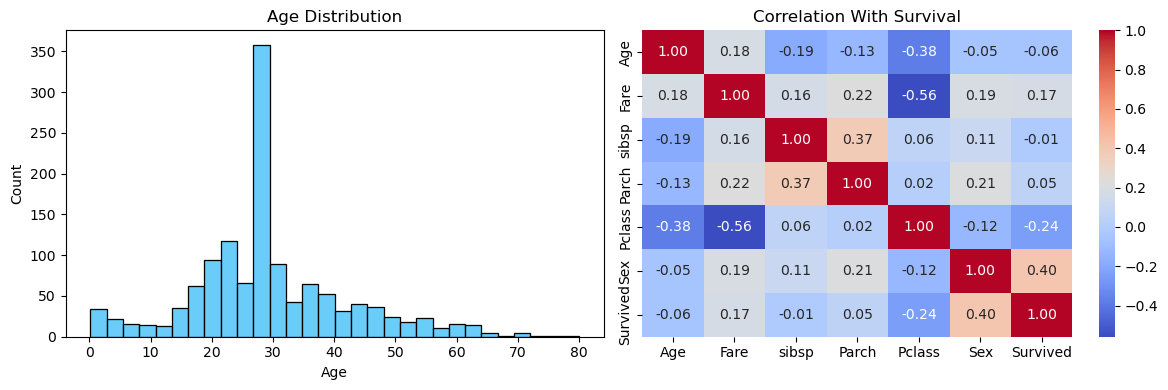

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(titanic["Age"], bins=30, color="#38BDF8", ax=axes[0])
axes[0].set_title("Age Distribution")

corr = titanic[["Age", "Fare", "sibsp", "Parch", "Pclass", "Sex", "Survived"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation With Survival")

plt.tight_layout()
plt.show()

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> From the correlation heatmap, <code>Sex</code> and <code>Pclass</code> typically show the strongest relationship with <code>Survived</code> in this dataset — a useful sanity check before trusting any model's later feature importances.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2b — Preprocess: encode categoricals and scale features (fit on train only)</h3>


In [6]:
from sklearn.model_selection import train_test_split

# Numeric features will be imputed and scaled
numeric_features = [
    "Age",
    "Fare",
    "sibsp",
    "Parch"
]

# These columns represent categories, even though their values are numbers
categorical_features = [
    "Sex",
    "Pclass",
    "Embarked"
]

# Combine all selected features
features = numeric_features + categorical_features

# Features and target
X = titanic[features].copy()
y = titanic["Survived"].copy()

# Split the data while preserving the target class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nMissing values in training data:")
print(X_train.isnull().sum())

Training features shape: (1047, 7)
Test features shape: (262, 7)

Numeric features:
['Age', 'Fare', 'sibsp', 'Parch']

Categorical features:
['Sex', 'Pclass', 'Embarked']

Missing values in training data:
Age         0
Fare        0
sibsp       0
Parch       0
Sex         0
Pclass      0
Embarked    2
dtype: int64


<div style="border-left:5px solid #38BDF8; background-color:#eef9ff;
padding:10px 15px; margin:10px 0; border-radius:4px; color:#075985;">

<b>Preprocessing Pipeline:</b>
Numeric features will have missing values filled with the median, then they
will be standardized. Categorical features will have missing values filled
with the most frequent category, then they will be converted using one-hot
encoding. The preprocessing steps are fitted on the training data only to
prevent data leakage.

</div>

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Preprocessing steps for numeric features
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# Preprocessing steps for categorical features
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)


# Apply the correct preprocessing to each feature type
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# Learn preprocessing information from training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same learned transformations to test data
X_test_processed = preprocessor.transform(X_test)


print("Training data before preprocessing:", X_train.shape)
print("Training data after preprocessing:", X_train_processed.shape)

print("\nTest data before preprocessing:", X_test.shape)
print("Test data after preprocessing:", X_test_processed.shape)

print("\nPreprocessing completed without data leakage.")

Training data before preprocessing: (1047, 7)
Training data after preprocessing: (1047, 12)

Test data before preprocessing: (262, 7)
Test data after preprocessing: (262, 12)

Preprocessing completed without data leakage.


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Train at least two models and evaluate against a baseline</h3>


In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# Baseline and classification models
models = {
    "Baseline": DummyClassifier(
        strategy="most_frequent",
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}


results = []


for model_name, model in models.items():

    # Train the model
    model.fit(
        X_train_processed,
        y_train
    )

    # Make predictions
    predictions = model.predict(
        X_test_processed
    )

    # Store evaluation results
    results.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1-score": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })


# Create and display the comparison table
results_table = pd.DataFrame(results)

results_table = results_table.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)


display(
    results_table.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1-score": "{:.3f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.756,0.532,0.485,0.508
1,Logistic Regression,0.748,0.521,0.368,0.431
2,Baseline,0.740,0.000,0.000,0.000


In [9]:
# Separate the baseline from the real models
baseline_row = results_table[
    results_table["Model"] == "Baseline"
].iloc[0]

real_models = results_table[
    results_table["Model"] != "Baseline"
].copy()

# Select the best real model using F1-score
best_model_row = real_models.loc[
    real_models["F1-score"].idxmax()
]

baseline_f1 = baseline_row["F1-score"]
best_model_name = best_model_row["Model"]
best_model_f1 = best_model_row["F1-score"]

f1_improvement = best_model_f1 - baseline_f1


print("Best model:", best_model_name)
print(f"Best model F1-score: {best_model_f1:.3f}")
print(f"Baseline F1-score: {baseline_f1:.3f}")
print(f"Improvement over baseline: {f1_improvement:.3f}")

Best model: Random Forest
Best model F1-score: 0.508
Baseline F1-score: 0.000
Improvement over baseline: 0.508


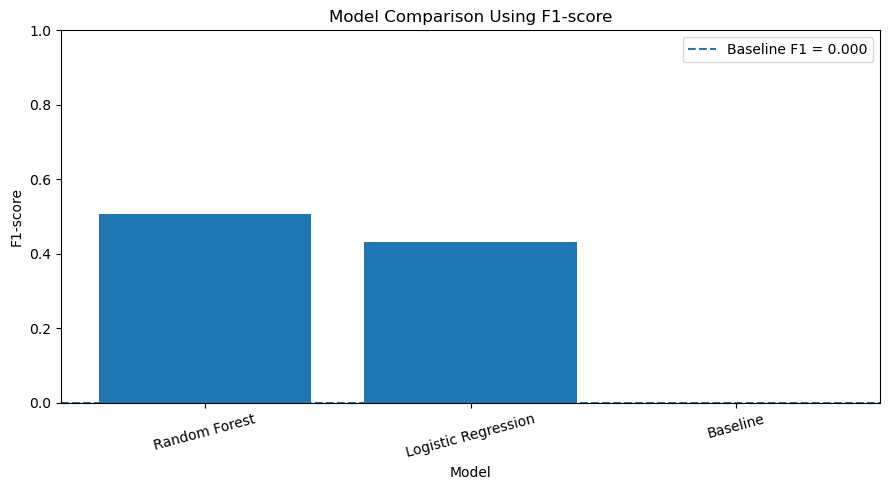

In [10]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_table["Model"],
    results_table["F1-score"]
)

plt.axhline(
    y=baseline_f1,
    linestyle="--",
    label=f"Baseline F1 = {baseline_f1:.3f}"
)

plt.title("Model Comparison Using F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()

plt.show()

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> The <b>baseline</b> row always predicts the single most common class ("did not survive"). Any model that cannot clearly beat this baseline on F1-score has not learned anything useful from the features — exactly the same baseline discipline used for regression back on Day 2.
</div>


In [11]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Retrieve the best trained model
best_model = models[best_model_name]

# Generate predictions using the best model
best_model_predictions = best_model.predict(
    X_test_processed
)

print("Best Model:", best_model_name)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_model_predictions,
        target_names=[
            "Did Not Survive",
            "Survived"
        ],
        zero_division=0
    )
)

Best Model: Random Forest

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.85      0.84       194
       Survived       0.53      0.49      0.51        68

       accuracy                           0.76       262
      macro avg       0.68      0.67      0.67       262
   weighted avg       0.75      0.76      0.75       262



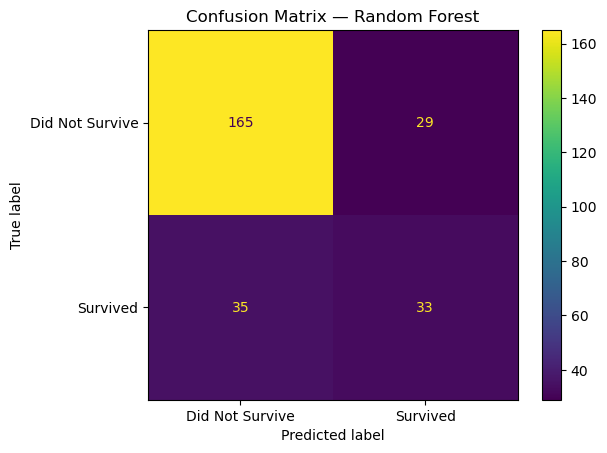

In [12]:
confusion = confusion_matrix(
    y_test,
    best_model_predictions
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        "Did Not Survive",
        "Survived"
    ]
)

display_matrix.plot()

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.show()

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Select the better model, justify the choice, and document the pipeline</h3>


In [13]:
print(f"Best model  : {best_model_name}")
print(f"Best F1     : {best_model_f1:.3f}")
print(f"Baseline F1 : {baseline_f1:.3f}")
print(f"Improvement over baseline: {f1_improvement:+.3f}")

Best model  : Random Forest
Best F1     : 0.508
Baseline F1 : 0.000
Improvement over baseline: +0.508


In [15]:
from IPython.display import Markdown, display

# Get the best model's detailed metrics
best_accuracy = best_model_row["Accuracy"]
best_precision = best_model_row["Precision"]
best_recall = best_model_row["Recall"]
best_f1 = best_model_row["F1-score"]

final_conclusion = f"""
<div style="border-left:5px solid #BE185D; background-color:#fff0f6;
padding:12px 16px; margin:10px 0; border-radius:4px; color:#7a0d3d;">

<b>Final Project Conclusion:</b><br><br>

The <b>{best_model_name}</b> was the best-performing model, achieving an
F1-score of <b>{best_f1:.3f}</b>, compared with <b>{baseline_f1:.3f}</b>
for the majority-class baseline. This represents an improvement of
<b>{f1_improvement:.3f}</b> in F1-score, showing that the model learned
useful patterns from the passenger data. Random Forest likely performed
best because it can capture nonlinear relationships and interactions
between features such as passenger class, sex, age, fare, and embarkation
point.

The model achieved an accuracy of <b>{best_accuracy:.3f}</b>, precision of
<b>{best_precision:.3f}</b>, and recall of <b>{best_recall:.3f}</b>.
The preprocessing pipeline handled missing values, encoded categorical
features, and scaled numeric features using training data only, which prevented
data leakage and ensured an honest evaluation.

</div>
"""

display(Markdown(final_conclusion))


<div style="border-left:5px solid #BE185D; background-color:#fff0f6;
padding:12px 16px; margin:10px 0; border-radius:4px; color:#7a0d3d;">

<b>Final Project Conclusion:</b><br><br>

The <b>Random Forest</b> was the best-performing model, achieving an
F1-score of <b>0.508</b>, compared with <b>0.000</b>
for the majority-class baseline. This represents an improvement of
<b>0.508</b> in F1-score, showing that the model learned
useful patterns from the passenger data. Random Forest likely performed
best because it can capture nonlinear relationships and interactions
between features such as passenger class, sex, age, fare, and embarkation
point.

The model achieved an accuracy of <b>0.756</b>, precision of
<b>0.532</b>, and recall of <b>0.485</b>.
The preprocessing pipeline handled missing values, encoded categorical
features, and scaled numeric features using training data only, which prevented
data leakage and ensured an honest evaluation.

</div>


<a id="section8"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">8. Best Practices &amp; Reproducibility</h2>
<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> <ul>
<li>Always fix <code>random_state=42</code> for both the train/test split and any randomized model.</li>
<li>Fit every preprocessing step (scaler, encoder) on the training data only.</li>
<li>Always include a baseline in the results table — never report a lone metric.</li>
<li>Choose the evaluation metric based on the problem, before looking at results.</li>
<li>Narrate every stage in Markdown: a working notebook without explanation is an unfinished deliverable.</li>
<li>Commit the finished notebook to GitHub with a clear, descriptive commit message.</li>
</ul>
</div>


<a id="section9"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">9. Summary — What I Learned This Week</h2>
<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> <ul>
<li><b>Day 1</b> set up the Scikit-learn workflow: features/target, train/test split, the fit-predict-score pattern.</li>
<li><b>Day 2</b> trained a <b>Linear Regression</b> model and evaluated it with MAE, RMSE, and R&sup2; against a baseline.</li>
<li><b>Day 3</b> trained a <b>Logistic Regression</b> classifier and learned the confusion matrix, precision/recall/F1, and AUC-ROC.</li>
<li><b>Day 4</b> compared <b>decision trees, random forests, SVMs, and k-NN</b> fairly on the same split and metric.</li>
<li><b>Day 5</b> combined everything into one full pipeline — EDA, leak-free preprocessing, multiple models, and an honest evaluation against a baseline.</li>
<li>This exact five-stage pipeline is the foundation for every remaining project in the program, including the <b>Phase 3 capstone</b>.</li>
</ul>
</div>
